In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

sys.path.append(os.path.dirname(os.getcwd()))
from lib.utils import get_sequence_data
from lib.BLogistic import SkewedBLogistic, train_blogistic

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

folder_path = r"../../MarketData/historical_data"
context_window = 60
X, Y = get_sequence_data(folder_path, context_window, force_recompute=True)
dof = 16
simple_X = torch.tensor(X[:, :, 0], device=device)
simple_Y = torch.tensor(Y, device=device).reshape(-1, 1)

dev_size = 10000
np.random.seed(0)
indices = np.random.permutation(simple_X.shape[0])

dev_indices = indices[:dev_size]
train_indices = indices[dev_size:]
train_X = simple_X[train_indices]
train_Y = simple_Y[train_indices]
dev_X = simple_X[dev_indices, :]
dev_Y = simple_Y[dev_indices]

std = train_Y.std()
train_X = train_X / std
train_Y = train_Y / std
dev_X = dev_X / std
dev_Y = dev_Y / std
print("train_X", train_X.shape, "train_Y", train_Y.shape, "dev_X", dev_X.shape, "dev_Y", dev_Y.shape)
print("std", std, train_X.std())

../../MarketData/historical_data
1256
skipping 2020-11-27
skipping 2020-12-24
skipping 2021-11-26
skipping 2022-11-25
skipping 2023-07-03
skipping 2023-11-24
skipping 2024-07-03
skipping 2024-11-29
skipping 2024-12-24
skipping 2025-07-03
train_X torch.Size([402426, 60]) train_Y torch.Size([402426, 1]) dev_X torch.Size([10000, 60]) dev_Y torch.Size([10000, 1])
std tensor(0.0004, device='cuda:0') tensor(1.0232, device='cuda:0')


In [2]:
class CNNProbNN(nn.Module):
    def __init__(self, context_window, dof, device):
        super(CNNProbNN, self).__init__()
        self.context_window = context_window
        self.dof = dof
        self.device = device

        print(f"\nInitializing CNN with context_window={context_window}, dof={dof}")

        # CNN layers
        self.conv1 = nn.Conv1d(
            in_channels=1,
            #out_channels=256,
            out_channels=16,
            kernel_size=3, #2
            padding=1, # 0
            stride=1
        )
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.conv1 = self.conv1.float()

        # with torch.no_grad():
        #     dummy = torch.zeros(1, 1, context_window, dtype=torch.float32)
        #     out = self.conv1(dummy)
        #     out = self.pool(out)
        #     out = self.flatten(out)
        #     self.flattened_size = int(out.shape[1])

        with torch.no_grad():
            dummy = torch.zeros(1, 1, context_window, dtype=torch.float32)
            out = self.conv1(dummy)
            out = self.flatten(out)
            self.flattened_size = int(out.shape[1])

        # Dense layers
        # self.fc1 = nn.Linear(self.flattened_size, context_window)
        # self.fc2 = nn.Linear(context_window, dof)
        self.fc = nn.Linear(self.flattened_size, dof)
        self.fc = self.fc.float()
        nn.init.uniform_(self.fc.weight, -0.01, 0.01)
        nn.init.zeros_(self.fc.bias)

        # Convert to float32
        # self.fc1 = self.fc1.float()
        # self.fc2 = self.fc2.float()

        # for m in [self.fc1, self.fc2]:
        #     nn.init.uniform_(m.weight, -0.01, 0.01)
        #     nn.init.zeros_(m.bias)

        # BLogistic distribution handler
        self.blogistic = SkewedBLogistic(dof - 3, device=device)

        if hasattr(self.blogistic, 'bernstein_to_standard_matrix_torch'):
            self.blogistic.bernstein_to_standard_matrix_torch = \
                self.blogistic.bernstein_to_standard_matrix_torch.float()

        print("Model initialized successfully!\n")

    # def forward(self, x):
    #     # Ensure input is the right type and shape
    #     if x.dim() == 2:
    #         x = x.unsqueeze(1)
    #
    #     z = torch.relu(self.conv1(x))
    #     z = self.pool(z)
    #     z = self.flatten(z)
    #     z = torch.relu(self.fc1(z))
    #     params = self.fc2(z)
    #     return params
    #
    # def get_params(self, x):
    #     if x.dim() == 2:
    #         x = x.unsqueeze(1)
    #
    #     z = torch.relu(self.conv1(x))
    #     z = self.pool(z)
    #     z = self.flatten(z)
    #     z = torch.relu(self.fc1(z))
    #     params = self.fc2(z)
    #     return params

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)

        z = torch.relu(self.conv1(x))
        z = self.flatten(z)
        params = self.fc(z)
        return params

    def get_params(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)

        z = torch.relu(self.conv1(x))
        z = self.flatten(z)
        params = self.fc(z)
        return params

    def loss_fn(self, x, y):
        params = self.forward(x)
        logpdf = self.blogistic.logpdf_vectorized(
            y, params[:, :-2], params[:, -2], params[:, -1]
        )
        return -logpdf.mean()

    def get_logpdf(self, x, sample_xs):
        params = self.get_params(x)
        return self.blogistic.logpdf(sample_xs, params[:, :-2].flatten(),
                                     params[:, -2], params[:, -1])

    def get_pdf(self, x, sample_xs):
        return torch.exp(self.get_logpdf(x, sample_xs))

    def get_pdf_batched(self, x, sample_xs, batch_size=1000):
        """Compute PDF in batches to avoid OOM"""
        all_pdfs = []
        for i in range(0, len(sample_xs), batch_size):
            batch = sample_xs[i:i+batch_size]
            pdf_batch = self.get_pdf(x, batch)
            all_pdfs.append(pdf_batch.detach().cpu())
        return torch.cat(all_pdfs)

In [3]:
def train_cnn_nn(
    train_X, train_Y, dev_X, dev_Y,
    lr, num_steps, device,
    transfer_learn=True,
    batch_size=8192
):
    # Convert all data to float32
    train_X = train_X.float().to(device)
    train_Y = train_Y.float().to(device)
    dev_X = dev_X.float().to(device)
    dev_Y = dev_Y.float().to(device)

    print(f"Train X shape: {train_X.shape}, Train Y shape: {train_Y.shape}")
    print(f"Using batch_size={batch_size}")

    # Initialize model
    model = CNNProbNN(context_window, dof, device).to(device)

    # Optional transfer learning initialization
    if transfer_learn:
        iid_train_steps = 500
        iid_lr = 0.05
        _, offset = train_blogistic(
            train_Y.flatten(), dof, iid_lr, iid_train_steps,
            allow_skew=True, device=device
        )
        with torch.no_grad():
            offset = [o.float() for o in offset]
            model.fc.bias[:-2].copy_(offset[0])
            model.fc.bias[-2].copy_(offset[1])
            model.fc.bias[-1].copy_(offset[2])
            # model.fc2.bias[:-2].copy_(offset[0])
            # model.fc2.bias[-2].copy_(offset[1])
            # model.fc2.bias[-1].copy_(offset[2])

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    train_losses, dev_losses = [], []

    # Training loop
    for step in range(num_steps):
        model.train()
        running_loss = 0.0
        n_batches = 0

        for i in range(0, train_X.shape[0], batch_size):
            batch_X = train_X[i:i+batch_size]
            batch_Y = train_Y[i:i+batch_size]
            if batch_X.shape[0] == 0:
                continue

            loss = model.loss_fn(batch_X, batch_Y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        avg_train_loss = running_loss / max(n_batches, 1)

        # Periodic validation
        if step % 100 == 0:
            model.eval()
            with torch.no_grad():
                dev_loss_sum = 0.0
                n_dev_batches = 0
                for j in range(0, dev_X.shape[0], batch_size):
                    batch_X = dev_X[j:j+batch_size]
                    batch_Y = dev_Y[j:j+batch_size]
                    if batch_X.shape[0] == 0:
                        continue
                    dev_loss_sum += model.loss_fn(batch_X, batch_Y).item()
                    n_dev_batches += 1
                avg_dev_loss = dev_loss_sum / max(n_dev_batches, 1)

            train_losses.append(avg_train_loss)
            dev_losses.append(avg_dev_loss)
            print(f"[Step {step}] Train Loss: {avg_train_loss:.4f}, Dev Loss: {avg_dev_loss:.4f}")

    print(f"Final Train Loss: {avg_train_loss:.4f}, Final Dev Loss: {avg_dev_loss:.4f}")
    return model, train_losses, dev_losses



In [ ]:
print(f"Context window: {context_window}")
print(f"DOF: {dof}")
print(f"Device: {device}")

# Training
lr = 2e-4
num_steps = 3000
model, train_losses, dev_losses = train_cnn_nn(train_X, train_Y, dev_X, dev_Y, lr, num_steps, device=device)
torch.save(model.state_dict(), f"jl_simple_cnn_model_context{context_window}.pth")

# Loading and plotting
model = CNNProbNN(context_window, dof, device).to(device)
model.load_state_dict(torch.load(f"jl_simple_cnn_model_context{context_window}.pth", map_location=device))
model.eval()

Context window: 60
DOF: 16
Device: cuda
Train X shape: torch.Size([402426, 60]), Train Y shape: torch.Size([402426, 1])
Using batch_size=8192

Initializing CNN with context_window=60, dof=16
Model initialized successfully!

Step 100, Loss: 1.2518
Step 200, Loss: 1.2507
Step 300, Loss: 1.2503
Step 400, Loss: 1.2500
Step 500, Loss: 1.2498
Step 500, Final Loss: 1.2498
[Step 0] Train Loss: 1.1616, Dev Loss: 1.1265
[Step 100] Train Loss: 1.0814, Dev Loss: 1.0971


Patched lib.BLogistic.DT to float32
Creating fresh model on CPU for plotting...

Initializing CNN with context_window=60, dof=16
Model initialized successfully!



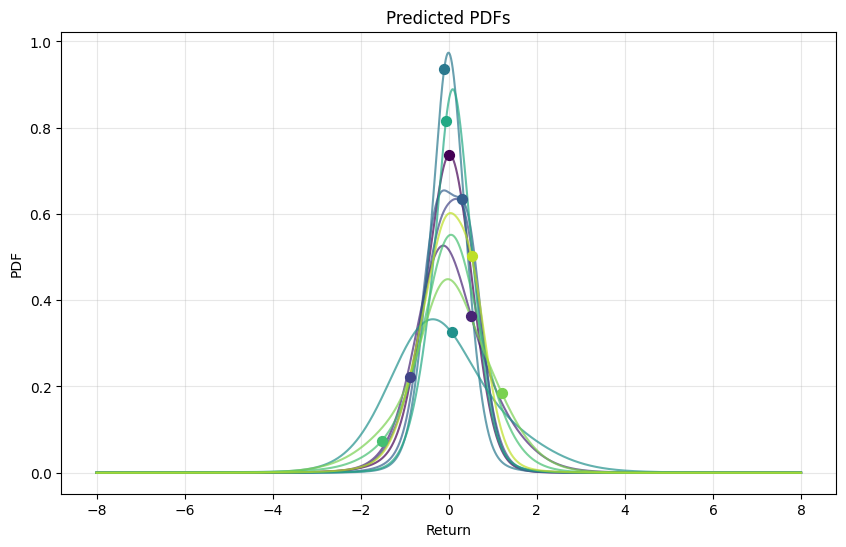

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import sys
for module_name in list(sys.modules.keys()):
    if 'BLogistic' in module_name or 'blogistic' in module_name.lower():
        module = sys.modules[module_name]
        if hasattr(module, 'DT'):
            module.DT = torch.float32
            print(f"Patched {module_name}.DT to float32")

torch.set_default_dtype(torch.float32)

print("Creating fresh model on CPU for plotting...")

dev_X_cpu = dev_X.cpu()
dev_Y_cpu = dev_Y.cpu()

model_cpu = CNNProbNN(context_window, dof, device='cpu')

state_dict = torch.load(f"jl_simple_cnn_model_context{context_window}.pth", map_location='cpu')
model_cpu.load_state_dict(state_dict)
model_cpu.eval()

# Create plot tensors on CPU
plot_xs = torch.linspace(-8, 8, 10000, dtype=torch.float32, device='cpu')
nplots = min(10, dev_X_cpu.shape[0])

plt.figure(figsize=(10, 6))
with torch.no_grad():
    for idx in range(nplots):
        color = plt.cm.viridis(idx / nplots)

        x_input = dev_X_cpu[idx, :].reshape(1, -1).float()
        y_input = dev_Y_cpu[idx, :].float()

        plot_ys = model_cpu.get_pdf_batched(x_input, plot_xs, batch_size=500)
        plt.plot(plot_xs.numpy(), plot_ys.numpy(), color=color, alpha=0.7)

        point_pdf = model_cpu.get_pdf(x_input, y_input.reshape(-1))
        plt.scatter(y_input.numpy(), point_pdf.numpy(), color=color, s=50, zorder=5)

plt.xlabel("Return")
plt.ylabel("PDF")
plt.title("Predicted PDFs")
plt.grid(True, alpha=0.3)
plt.show()